In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import os
import ssl
from glob import glob
from PIL import Image
import random

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

## kiểm tra cuda

In [17]:
print("Có GPU không? :", torch.cuda.is_available())  # Phải trả về True
print("Phiên bản CUDA trong PyTorch:", torch.version.cuda)
print("Tên GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Không có GPU")

# Kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng: {device}") # phải là: Đang sử dụng: cuda

Có GPU không? : True
Phiên bản CUDA trong PyTorch: 11.8
Tên GPU: NVIDIA GeForce GTX 1650
Đang sử dụng: cuda


## load dữ liệu và chia ngẫu nhiên theo tỉ lệ 90:5:5

In [18]:
# Định nghĩa đường dẫn thư mục chứa dữ liệu
data_dir = "data/cic_ddos_2019_images"
train_data, valid_data, test_data = [], [], []
label_map = {}  # Mapping nhãn -> số


for label_idx, label in enumerate(os.listdir(data_dir)):
    label_path = os.path.join(data_dir, label)
    if not os.path.isdir(label_path):
        continue
    
    # Lưu ánh xạ nhãn
    label_map[label] = label_idx
    
    # Lấy danh sách ảnh
    image_paths = glob(os.path.join(label_path, "*"))
    random.shuffle(image_paths)
    
    # Chia tập dữ liệu theo tỷ lệ 90:5:5
    ratito_1 = 0.9
    ratito_2 = 0.05

    total = len(image_paths)
    train_split = int(ratito_1 * total)
    valid_split = int((ratito_1+ratito_2) * total)

    train_data.extend([(p, label_idx) for p in image_paths[:train_split]])
    valid_data.extend([(p, label_idx) for p in image_paths[train_split:valid_split]])
    test_data.extend([(p, label_idx) for p in image_paths[valid_split:]])

In [19]:
# Kiểm tra số lượng mẫu mỗi tập
print(f"Train: {len(train_data)}, Valid: {len(valid_data)}, Test: {len(test_data)}")

# Hiển thị một số đường dẫn ảnh từ mỗi tập (kiểm tra kết quả)
print("Sample train images:", train_data[:3])
print("Sample valid images:", valid_data[:3])
print("Sample test images:", test_data[:3])
print("labels: ", label_map)

Train: 720, Valid: 40, Test: 40
Sample train images: [('data/cic_ddos_2019_images\\BENIGN\\35.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\92.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\50.png', 0)]
Sample valid images: [('data/cic_ddos_2019_images\\BENIGN\\63.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\29.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\56.png', 0)]
Sample test images: [('data/cic_ddos_2019_images\\BENIGN\\27.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\42.png', 0), ('data/cic_ddos_2019_images\\BENIGN\\30.png', 0)]
labels:  {'BENIGN': 0, 'LDAP': 1, 'MSSQL': 2, 'NetBIOS': 3, 'Portmap': 4, 'Syn': 5, 'UDP': 6, 'UDPLag': 7}


## train

In [20]:
# Định nghĩa Dataset
class ImageDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

In [21]:
# Định nghĩa các phép biến đổi dữ liệu
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Resize ảnh về kích thước chuẩn
    transforms.ToTensor(), # Chuyển ảnh thành tensor
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # Chuẩn hóa theo ImageNet
])

# Tạo DataLoader
batch_size = 32
train_loader = DataLoader(ImageDataset(train_data, transform), batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(ImageDataset(valid_data, transform), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(ImageDataset(test_data, transform), batch_size=batch_size, shuffle=False)

# Số lớp đầu ra
num_classes = len(label_map.keys())
print(num_classes)

8


In [22]:
# Kiểm tra thiết bị (GPU nếu có)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [23]:
# Sử dụng khi thuê GPU trên máy ảo để tải base model
ssl._create_default_https_context = ssl._create_unverified_context

In [24]:
# Load mô hình ResNet50 đã pretrain
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(label_map.keys()))  # Adjust output layer
model = model.to(device)

In [25]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [26]:
# Training function
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10):
    train_losses, valid_losses, train_accs, valid_accs = [], [], [], []
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_losses.append(running_loss / len(train_loader))
        train_accs.append(correct / total)
        
        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        valid_losses.append(val_loss / len(valid_loader))
        valid_accs.append(val_correct / val_total)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f} - Valid Loss: {valid_losses[-1]:.4f} - Train Acc: {train_accs[-1]:.4f} - Valid Acc: {valid_accs[-1]:.4f}")
    return train_losses, valid_losses, train_accs, valid_accs

In [27]:
# Train model
train_losses, valid_losses, train_accs, valid_accs = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=10)

Epoch 1/10 - Train Loss: 0.9741 - Valid Loss: 0.7182 - Train Acc: 0.7278 - Valid Acc: 0.8250
Epoch 2/10 - Train Loss: 0.0723 - Valid Loss: 0.0082 - Train Acc: 0.9889 - Valid Acc: 1.0000
Epoch 3/10 - Train Loss: 0.0103 - Valid Loss: 0.0035 - Train Acc: 1.0000 - Valid Acc: 1.0000
Epoch 4/10 - Train Loss: 0.0091 - Valid Loss: 0.0028 - Train Acc: 0.9972 - Valid Acc: 1.0000
Epoch 5/10 - Train Loss: 0.0049 - Valid Loss: 0.0019 - Train Acc: 1.0000 - Valid Acc: 1.0000
Epoch 6/10 - Train Loss: 0.0031 - Valid Loss: 0.0012 - Train Acc: 1.0000 - Valid Acc: 1.0000
Epoch 7/10 - Train Loss: 0.0028 - Valid Loss: 0.0008 - Train Acc: 1.0000 - Valid Acc: 1.0000
Epoch 8/10 - Train Loss: 0.0029 - Valid Loss: 0.0010 - Train Acc: 1.0000 - Valid Acc: 1.0000
Epoch 9/10 - Train Loss: 0.0097 - Valid Loss: 0.0251 - Train Acc: 0.9958 - Valid Acc: 0.9750
Epoch 10/10 - Train Loss: 0.0119 - Valid Loss: 0.0015 - Train Acc: 0.9972 - Valid Acc: 1.0000


In [28]:
# Save trained model
torch.save(model.state_dict(), 'models/cic-ddos2019/resnet50_finetuned.pth')

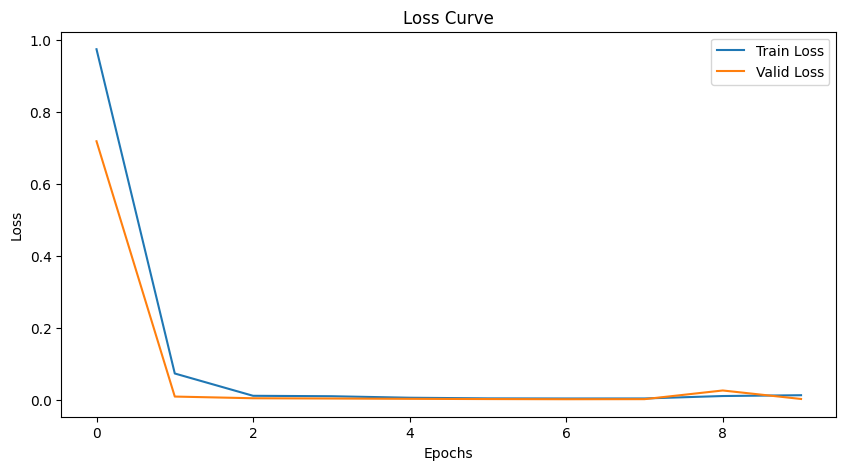

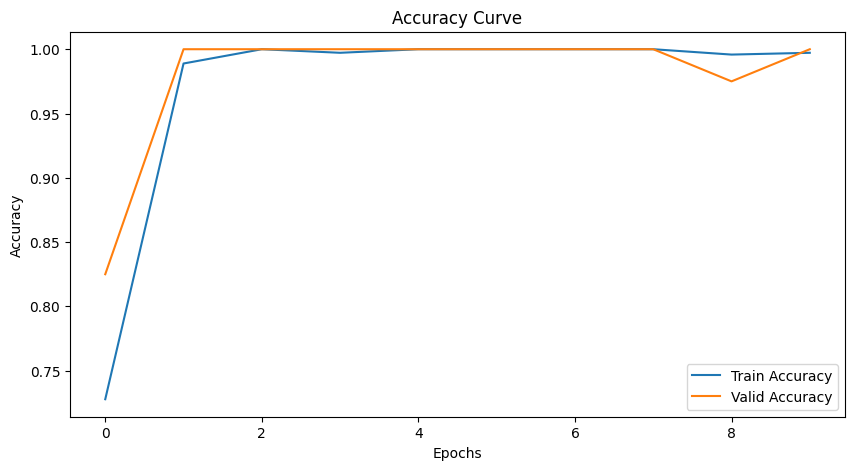

In [29]:
# Plot Loss Curve
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

# Plot Accuracy Curve
plt.figure(figsize=(10,5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(valid_accs, label='Valid Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()


## đánh giá

In [30]:
# Evaluate on test set
def evaluate_model(model, test_loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    return y_true, y_pred

y_true, y_pred = evaluate_model(model, test_loader)

In [32]:
# Classification report
print(classification_report(y_true, y_pred, target_names=label_map.keys()))

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00         5
        LDAP       1.00      1.00      1.00         5
       MSSQL       1.00      1.00      1.00         5
     NetBIOS       1.00      1.00      1.00         5
     Portmap       1.00      1.00      1.00         5
         Syn       1.00      1.00      1.00         5
         UDP       1.00      1.00      1.00         5
      UDPLag       1.00      1.00      1.00         5

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



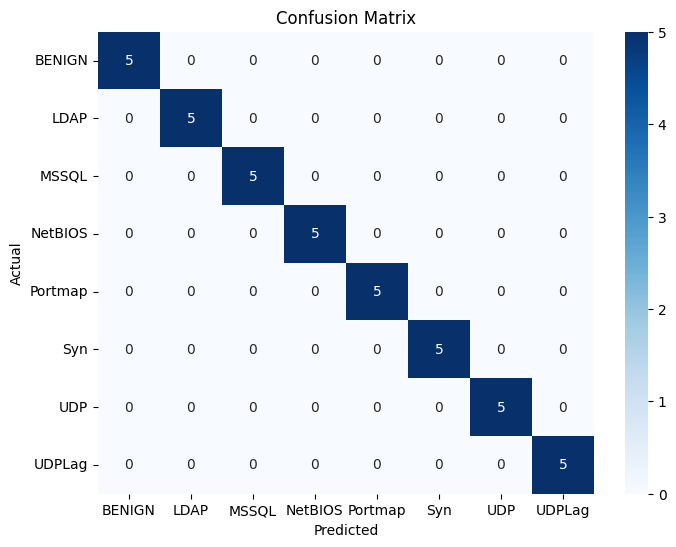

In [34]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


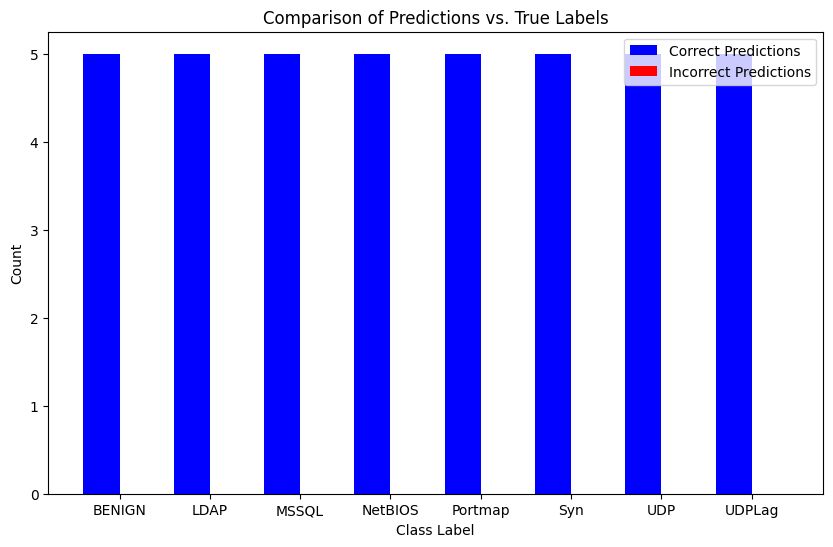

In [36]:
# Plot actual vs predicted labels
# actual_vs_pred_df = pd.DataFrame({'Actual': y_true, 'Predicted': y_pred})
# plt.figure(figsize=(10,6))
# sns.countplot(x='Actual', hue='Predicted', data=actual_vs_pred_df, palette='viridis')
# plt.xlabel('Actual Label')
# plt.ylabel('Count')
# plt.title('Actual vs Predicted Labels')
# plt.legend(title='Predicted Label')
# plt.show()

# Tạo DataFrame chứa nhãn thực tế và dự đoán
df = pd.DataFrame({"True Label": y_true, "Predicted Label": y_pred})

# Đếm số lượng dự đoán đúng và sai theo từng lớp
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

# Đếm số lượng đúng/sai theo từng lớp
correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

# Đảm bảo tất cả nhãn có trong bảng
correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()